In [3]:
# ============================================================
# Lead Scoring Prediction
# Author : Kushagra Modi
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns",None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
from google.colab import files

uploaded = files.upload()

Saving Lead Scoring.csv to Lead Scoring.csv


In [7]:
df = pd.read_csv("Lead Scoring.csv")

In [8]:
list(uploaded.keys())

['Lead Scoring.csv']

In [9]:
# Display first 5 rows

df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [10]:
# Dataset dimensions

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 9240
Columns : 37


In [11]:
# Basic information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [12]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lead Number,9240.0,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Converted,9240.0,0.385390,0.486714,0.0,0.0,0.0,1.00,1.0
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.00,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.00,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.00,55.0
Asymmetrique Activity Score,5022.0,14.306252,1.386694,7.0,14.0,14.0,15.00,18.0
Asymmetrique Profile Score,5022.0,16.344883,1.811395,11.0,15.0,16.0,18.00,20.0


In [13]:
# Check missing values

missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
Lead Quality,4767
Asymmetrique Profile Index,4218
Asymmetrique Activity Score,4218
Asymmetrique Activity Index,4218
Asymmetrique Profile Score,4218
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461


In [15]:
# Check duplicate records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [16]:
# Display column names

df.columns.tolist()

['Prospect ID',
 'Lead Number',
 'Lead Origin',
 'Lead Source',
 'Do Not Email',
 'Do Not Call',
 'Converted',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'Last Activity',
 'Country',
 'Specialization',
 'How did you hear about X Education',
 'What is your current occupation',
 'What matters most to you in choosing a course',
 'Search',
 'Magazine',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'Receive More Updates About Our Courses',
 'Tags',
 'Lead Quality',
 'Update me on Supply Chain Content',
 'Get updates on DM Content',
 'Lead Profile',
 'City',
 'Asymmetrique Activity Index',
 'Asymmetrique Profile Index',
 'Asymmetrique Activity Score',
 'Asymmetrique Profile Score',
 'I agree to pay the amount through cheque',
 'A free copy of Mastering The Interview',
 'Last Notable Activity']

In [17]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [18]:
print(df.shape)

(9240, 37)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [20]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
Lead Quality,4767
Asymmetrique Profile Index,4218
Asymmetrique Activity Score,4218
Asymmetrique Activity Index,4218
Asymmetrique Profile Score,4218
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461


In [21]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [22]:
print(df.shape)

(9240, 37)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [24]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
Lead Quality,4767
Asymmetrique Profile Index,4218
Asymmetrique Activity Score,4218
Asymmetrique Activity Index,4218
Asymmetrique Profile Score,4218
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461


In [25]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [26]:
df.shape

(9240, 37)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [28]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Prospect ID,9240,9240,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Number,9240.0,NaN,NaN,NaN,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
Lead Origin,9240,5,Landing Page Submission,4886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead Source,9204,21,Google,2868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Email,9240,2,No,8506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do Not Call,9240,2,No,9238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Converted,9240.0,NaN,NaN,NaN,0.38539,0.486714,0.0,0.0,0.0,1.0,1.0
TotalVisits,9103.0,NaN,NaN,NaN,3.445238,4.854853,0.0,1.0,3.0,5.0,251.0
Total Time Spent on Website,9240.0,NaN,NaN,NaN,487.698268,548.021466,0.0,12.0,248.0,936.0,2272.0
Page Views Per Visit,9103.0,NaN,NaN,NaN,2.36282,2.161418,0.0,1.0,2.0,3.0,55.0


In [29]:
df.isnull().sum().sort_values(ascending=False)

,0
Lead Quality,4767
Asymmetrique Profile Index,4218
Asymmetrique Activity Score,4218
Asymmetrique Activity Index,4218
Asymmetrique Profile Score,4218
Tags,3353
What matters most to you in choosing a course,2709
Lead Profile,2709
What is your current occupation,2690
Country,2461


In [30]:
# Missing values percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_df = missing_df.sort_values(by="Missing Percentage", ascending=False)

missing_df

,Missing Values,Missing Percentage
Lead Quality,4767,51.590909
Asymmetrique Profile Index,4218,45.649351
Asymmetrique Activity Score,4218,45.649351
Asymmetrique Activity Index,4218,45.649351
Asymmetrique Profile Score,4218,45.649351
Tags,3353,36.287879
What matters most to you in choosing a course,2709,29.318182
Lead Profile,2709,29.318182
What is your current occupation,2690,29.112554
Country,2461,26.634199


In [31]:
# Columns having more than 40% missing values

high_missing = missing_df[missing_df["Missing Percentage"] > 40]

high_missing

,Missing Values,Missing Percentage
Lead Quality,4767,51.590909
Asymmetrique Profile Index,4218,45.649351
Asymmetrique Activity Score,4218,45.649351
Asymmetrique Activity Index,4218,45.649351
Asymmetrique Profile Score,4218,45.649351


In [35]:
df.shape

(9240, 32)

In [36]:
df.drop(["Prospect ID", "Lead Number"], axis=1, errors="ignore", inplace=True)

print(df.shape)

(9240, 30)


In [37]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing[missing > 0]

,0
Tags,36.287879
What matters most to you in choosing a course,29.318182
Lead Profile,29.318182
What is your current occupation,29.112554
Country,26.634199
How did you hear about X Education,23.885281
Specialization,15.562771
City,15.367965
Page Views Per Visit,1.482684
TotalVisits,1.482684


In [39]:
# Fill missing values with "Not Specified" for categorical columns

categorical_fill = [
    "Tags",
    "Lead Profile",
    "What matters most to you in choosing a course",
    "What is your current occupation",
    "Country",
    "How did you hear about X Education",
    "Specialization",
    "City"
]

for col in categorical_fill:
    df[col] = df[col].fillna("Not Specified")

# Fill numerical columns with median
df["Page Views Per Visit"] = df["Page Views Per Visit"].fillna(df["Page Views Per Visit"].median())
df["TotalVisits"] = df["TotalVisits"].fillna(df["TotalVisits"].median())

# Fill Last Activity and Lead Source with mode
df["Last Activity"] = df["Last Activity"].fillna(df["Last Activity"].mode()[0])
df["Lead Source"] = df["Lead Source"].fillna(df["Lead Source"].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [40]:
df.isnull().sum().sort_values(ascending=False).head(15)

,0
Lead Origin,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0
Last Activity,0
Country,0


In [41]:
df["Converted"].value_counts()

,count
Converted,
0,5679
1,3561


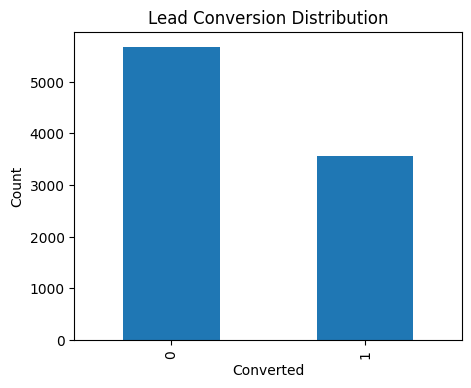

In [42]:
import matplotlib.pyplot as plt

df["Converted"].value_counts().plot(
    kind="bar",
    figsize=(5,4),
    title="Lead Conversion Distribution"
)

plt.xlabel("Converted")
plt.ylabel("Count")
plt.show()

In [44]:
# Separate features and target

X = df.drop("Converted", axis=1)
y = df["Converted"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (9240, 29)
Target Shape  : (9240,)


In [45]:
# Convert categorical columns into numeric

X = pd.get_dummies(X, drop_first=True)

print("Encoded Shape :", X.shape)

Encoded Shape : (9240, 182)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7392, 182)
(1848, 182)


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [48]:
# Separate Features and Target

X = df.drop("Converted", axis=1)
y = df["Converted"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (9240, 29)
y Shape: (9240,)


In [49]:
# Convert categorical columns into numeric

X = pd.get_dummies(X, drop_first=True)

print("Encoded Shape:", X.shape)

Encoded Shape: (9240, 182)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (7392, 182)
Testing Shape  : (1848, 182)


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9291125541125541

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1136
           1       0.92      0.89      0.91       712

    accuracy                           0.93      1848
   macro avg       0.93      0.92      0.92      1848
weighted avg       0.93      0.93      0.93      1848


Confusion Matrix:

[[1080   56]
 [  75  637]]


In [53]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:, 1]

print("ROC-AUC Score :", roc_auc_score(y_test, y_prob))

ROC-AUC Score : 0.9744879035448648


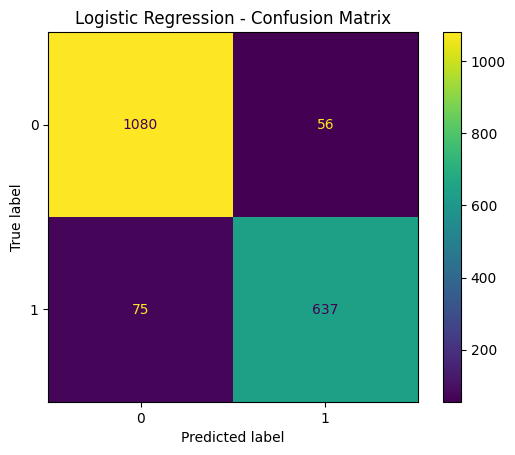

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy :", accuracy_score(y_test, y_pred_dt))
print("\nROC-AUC :", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy : 0.9188311688311688

ROC-AUC : 0.9164183662367462

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1136
           1       0.88      0.91      0.90       712

    accuracy                           0.92      1848
   macro avg       0.91      0.92      0.91      1848
weighted avg       0.92      0.92      0.92      1848



In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, y_pred_rf))
print("\nROC-AUC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy : 0.9296536796536796

ROC-AUC : 0.975591964709606

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1136
           1       0.91      0.90      0.91       712

    accuracy                           0.93      1848
   macro avg       0.93      0.92      0.93      1848
weighted avg       0.93      0.93      0.93      1848



In [57]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
}

comparison = pd.DataFrame(results)
comparison.sort_values("Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.929654
0,Logistic Regression,0.929113
1,Decision Tree,0.918831


In [58]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
146,Tags_Will revert after reading the email,0.176169
1,Total Time Spent on Website,0.118136
141,Tags_Ringing,0.060163
178,Last Notable Activity_SMS Sent,0.043597
156,Lead Profile_Potential Lead,0.034006
128,Tags_Closed by Horizzon,0.033246
138,Tags_Not Specified,0.032436
40,Last Activity_SMS Sent,0.030485
4,Lead Origin_Lead Add Form,0.027465
2,Page Views Per Visit,0.026887


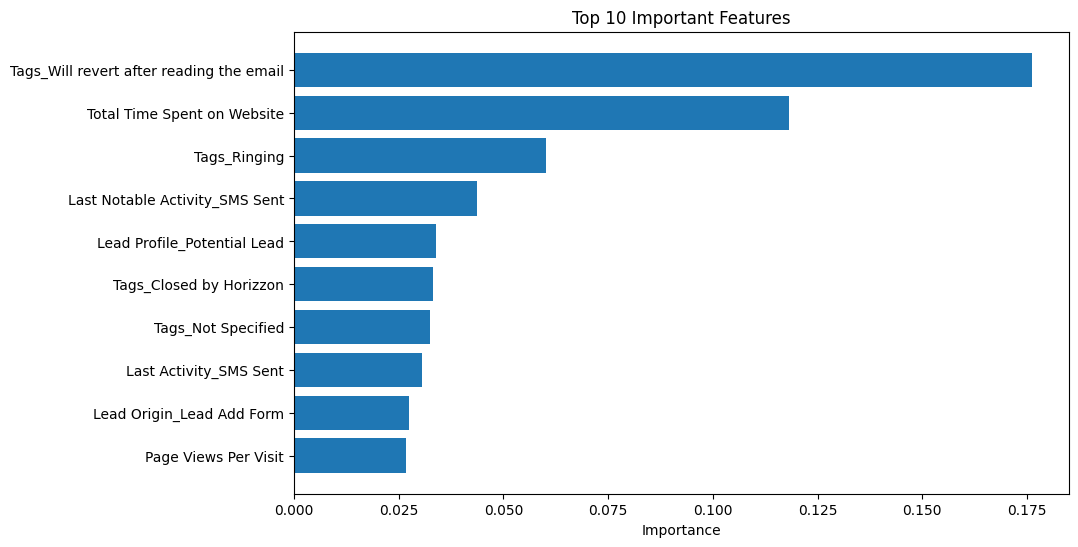

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [60]:
import joblib

joblib.dump(rf, "lead_scoring_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [61]:
from google.colab import files

files.download("lead_scoring_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>